In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [13]:
def min_max(x1, x2, axis=1):
    x1 = x1.T
    x2 = x2.T
    min = x2.min(axis=axis, keepdims=True)
    max = x2.max(axis=axis, keepdims=True)
    result = (x1-min)/(max-min)
    return result.T

In [14]:
d = np.loadtxt("elephant_data.txt",delimiter="\t", dtype='float')
Xd = d[:,0:-1]
yd = d[:,-1]

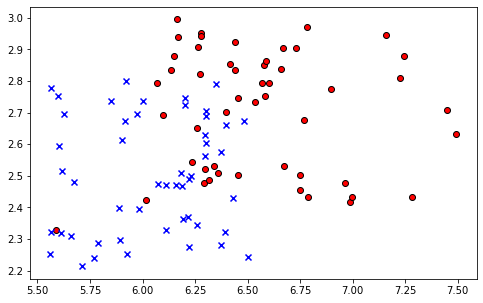

In [15]:
fig = plt.figure(1, figsize=(8, 5))
plt.clf()
markers = ['o', 'x', ',', '^', 'v', '*', '+', 'D']
colors =  ['r', 'b', 'g', 'k', 'c', 'm', 'y', 'grey']
m = 0
for i in set(yd):
    n = np.where(yd==i)
    plt.scatter(Xd[n, 0], Xd[n, 1], marker=markers[m], c=colors[m], zorder=10, edgecolors='k')
    m=m+1
plt.show()
fig.savefig("img1.png")
fig.savefig("img1.pdf")

In [76]:
X_train, X_test, y_train, y_test = train_test_split(Xd, yd, test_size=0.2, random_state=5)

In [77]:
X = min_max(X_train,X_train)
y = y_train

In [79]:
clf = svm.SVC()
result = clf.fit(X, y)
y_pred = clf.predict(X)
accuracy_score(y_pred,y)

0.8625

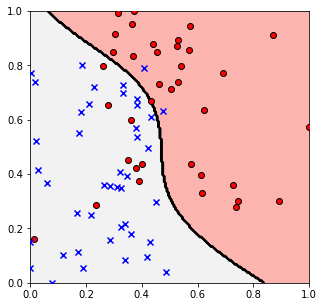

In [80]:
fig = plt.figure(1, figsize=(5, 5))
plt.clf()

markers = ['o', 'x', ',', '^', 'v', '*', '+', 'D']
colors =  ['r', 'b', 'g', 'k', 'c', 'm', 'y', 'grey']
m = 0
for i in set(y):
    n = np.where(y==i)
    plt.scatter(X[n, 0], X[n, 1], marker=markers[m], c=colors[m], zorder=10, edgecolors='k')
    m=m+1

plt.axis('tight')
x_min = min(X[:,0])
x_max = max(X[:,0])
y_min = min(X[:,1])
y_max = max(X[:,1])

XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
#Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
Z = clf.predict(np.c_[XX.ravel(), YY.ravel()])

# Put the result into a color plot
Z = Z.reshape(XX.shape)

plt.pcolormesh(XX, YY, Z, cmap=plt.cm.Pastel1)
plt.contour(XX, YY, Z, colors='k')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

#plt.xticks(())
#plt.yticks(())

plt.show()
fig.savefig("img2.png")
fig.savefig("img2.pdf")

In [81]:
X = min_max(X_test,X_train,axis=1)
y = y_test
#clf = svm.SVC()
#result = clf.fit(X, y)
y_pred = clf.predict(X)
accuracy_score(y_pred,y)

0.85

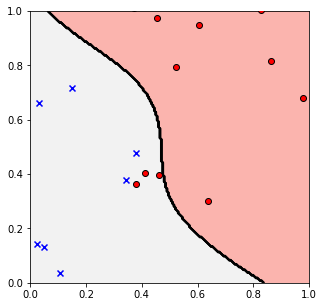

In [82]:
fig = plt.figure(1, figsize=(5, 5))
plt.clf()

markers = ['o', 'x', ',', '^', 'v', '*', '+', 'D']
colors =  ['r', 'b', 'g', 'k', 'c', 'm', 'y', 'grey']
m = 0
for i in set(y):
    n = np.where(y==i)
    plt.scatter(X[n, 0], X[n, 1], marker=markers[m], c=colors[m], zorder=10, edgecolors='k')
    m=m+1

plt.axis('tight')
#x_min = min(X[:,0])
#x_max = max(X[:,0])
#y_min = min(X[:,1])
#y_max = max(X[:,1])

XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
#Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])
#Z = clf.predict(np.c_[XX.ravel(), YY.ravel()])

# Put the result into a color plot
#Z = Z.reshape(XX.shape)

plt.pcolormesh(XX, YY, Z, cmap=plt.cm.Pastel1)
plt.contour(XX, YY, Z, colors='k')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

#plt.xticks(())
#plt.yticks(())

plt.show()
fig.savefig("img3.png")
fig.savefig("img3.pdf")